In [1]:
from micrograd.nn import MLP

In [2]:
from PIL import Image
import numpy as np

SIZE = 8

def load_image(path):
    img = Image.open(path)
    img = img.convert("RGB") #grayscale
    img = img.resize((SIZE,SIZE))

    #normalise to [0,1]
    pixels = np.array(img, dtype=np.float32).flatten() / 255.0
    return pixels

In [3]:
import os
import random

def load_dataset():
    x,y = [],[]

    for file in os.listdir("data/cake"):
        path = os.path.join("data/cake",file)
        x.append(load_image(path))
        y.append(1)

    for file in os.listdir("data/real"):
        path = os.path.join("data/real",file)
        x.append(load_image(path))
        y.append(0)

    merged = list(zip(x,y))
    random.shuffle(merged)

    x,y = zip(*merged)
    return list(x),list(y)
    

In [4]:
x, y = load_dataset()

print(len(x))
print(len(y))
print(len(x[0]))

100
100
192


In [5]:
split = int(0.8*len(x))

x_train, y_train = x[:split], y[:split]

x_test, y_test = x[split:], y[split:]


In [6]:
print(len(x_train))
print(len(x_test))

80
20


In [7]:
model = MLP(192, [16,8,1])

lr = 0.001
epochs = 100

In [8]:
x = x_train[0]
target = y_train[0]

pred = model(x)
print(pred)

loss = (pred - target)**2 #mean squared error
print(loss)

Value(data=-0.818608283996582, grad=0)
Value(data=3.3073360919952393, grad=0)


In [9]:
for p in model.parameters():
    p.grad = 0

loss.backward()
for p in model.parameters():
    p.data -= lr * p.grad

In [10]:
new_pred = model(x)

print(pred.data)
print(new_pred.data)

-0.8186083
1.940876


In [22]:
lr = 0.0001

losses = []

for epoch in range(1,21): # 18+20+20+20 from 124
    total_loss = 0
    for x, target in zip(x_train,y_train):
        pred = model(x)
        loss = (pred - target)**2
        
        for p in model.parameters():
            p.grad = 0
            
        loss.backward()

        for p in model.parameters():
            p.data -= lr * p.grad

        total_loss += loss.data
    
    losses.append(total_loss)
    print(epoch,total_loss)
        

1 19.946249
2 19.866947
3 19.792114
4 19.717373
5 19.646585
6 19.576849
7 19.50882
8 19.441513
9 19.375652
10 19.311438
11 19.248537
12 19.186876
13 19.126446
14 19.067192
15 19.009064
16 18.953321
17 18.895287
18 18.83945
19 18.784319
20 18.730194


In [23]:
correct = 0
for x, target in zip(x_test,y_test):
    pred = model(x).data
    prediction = 1 if pred > 0.5 else 0
    if (prediction == target):
        correct += 1

accuracy = correct/len(x_test)
print(accuracy)

0.6


In [28]:
train_correct = 0
for x, target in zip(x_train,y_train):
    pred = model(x).data
    prediction = 1 if pred > 0.5 else 0
    if (prediction == target):
        train_correct += 1

print(train_correct/len(x_train))

0.7


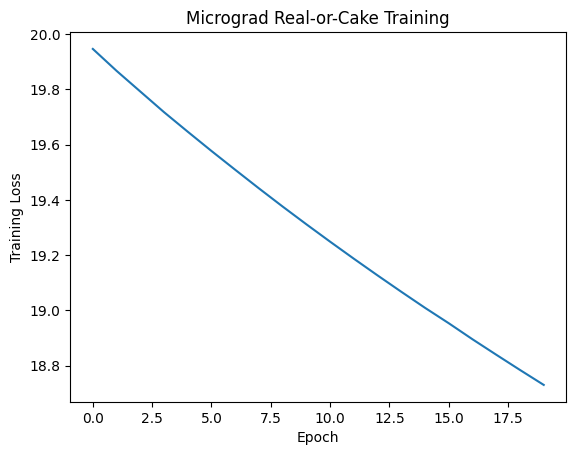

In [25]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Micrograd Real-or-Cake Training")
plt.show()

In [ ]:
weights = [p.data for p in model.parameters()]
import json
with open("weights.json","w") as f:
    json.dump(weights,f)